# Case Study for Statistical Methods

**Author Name**: Danish javaid Meo \
**Email**: danishjmeo@gmail.com\
**LinkedIn**: [link](https://www.linkedin.com/in/danish-javaid-4271a8231)\
**Kaggle**: [link](https://www.kaggle.com/danishjmeo)\
**Data set** : Tips

In [1]:
# import libraries
# !pip install pandas numpy matplotlib seaborn scipy statsmodels
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm  
from statsmodels.formula.api import ols


# 1.Chi-square Test

Assuming the expected distribution is 50% vegeterisn and 50% non-vegeterian .
you want to test if your sample data matches the  distribution

Goodness of fit

In [2]:
from scipy.stats import chisquare
# Hypothetical observed frequencies
observed_frequencies= np.array([30,70])  # e.g, 30 vegterians and 70 non vegeterians meals

# Expected Frequencies (assumin 50-50 distribution)
total_meals=observed_frequencies.sum()
expected_frequencies= np.array([total_meals*0.5,total_meals*0.5])

#perform the chi-square test
chi2_stat,p_value= chisquare(observed_frequencies,f_exp=expected_frequencies)

# output the result
print(f"chi-square statistics:{chi2_stat}")
print(f"p_value:{p_value}")

# print results with if and else conditions
if p_value <0.05:
    print("Reject null hypothesis ,there is a significant difference between the groups")
else:
    print("Fail to reject null hypothesis , there is no significant difference between both groups")

chi-square statistics:16.0
p_value:6.334248366623988e-05
Reject null hypothesis ,there is a significant difference between the groups


#  chi-square contingency 

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency

# data load
df= sns.load_dataset('tips')
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# we are applying our test on two categorical columns
contingency_table=pd.crosstab(df['sex'],df['smoker']) # we can also use another column like 'time'
contingency_table

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [5]:
# perform chi-square test

chi2, p , dof, expected =chi2_contingency(contingency_table)
print(f"chi_square statistics:{chi2}")
print(f'p_value:{p}')
print(f'degree of freedom:{dof}')
print(f'expected:{expected}')

# print using if else conditions

if p <0.05:
    print("Reject null hypothesis,There is significant difference between groups")
else:
    print("Fail to reject null hypothesis, There is no signficant difference between groups")

chi_square statistics:0.0
p_value:1.0
degree of freedom:1
expected:[[59.84016393 97.15983607]
 [33.15983607 53.84016393]]
Fail to reject null hypothesis, There is no signficant difference between groups


- we can apply on another columns like 'sex' and 'time', 'sex' and  'days' , 'smoker' and 'days'

---
---

 # 2. T-test

## One sample t-test

In [6]:
# libraries already imported
# load the datset

df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='Count'>

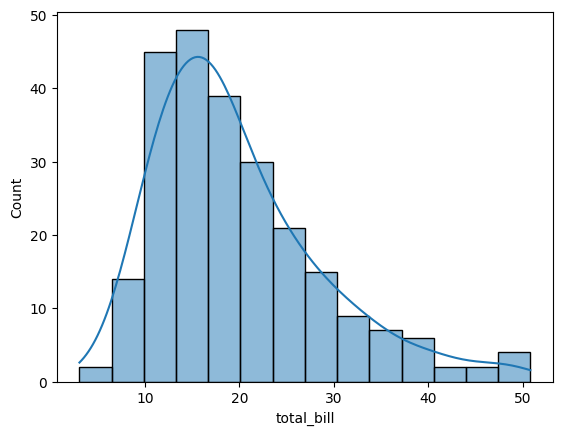

In [7]:
sns.histplot(df['total_bill'],kde=True)

In [8]:
# shapiro wilk test to see the noemality of test

stat,p= stats.shapiro(df['total_bill'])

# print results using if else conditions
print(f"statitic:{stat}")
print(f"p-value:{p}")

if p < 0.05:
    print("Reject null hypothesis, data is not normally distributed")
else:
    print("Fail to reject null hypothesis, data is normally distributed")

statitic:0.9197187941346584
p-value:3.324539186809091e-10
Reject null hypothesis, data is not normally distributed


## Two sample independent test

In [9]:
df.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [10]:
# lets run the two sample t test on total bill of male and female from tips dataset

total_bills_of_male = df[df['sex'] == 'male']['total_bill']
total_bills_of_females = df[df['sex'] == 'female']['total_bill']

statistic, p = stats.ttest_ind(total_bills_of_male,total_bills_of_females)


# print the results based on p value and if else conditions
if p < 0.05:
    print(f"Reject null hypothesis, because p vaule: {p} , there is a significant difference between total bill  of male and female customers of hotel")
else:
    print(f"Fail to reject null hypothesis,because p vaule: {p}, there is not any differences between total bill of female and male customers of hotel.")

Fail to reject null hypothesis,because p vaule: nan, there is not any differences between total bill of female and male customers of hotel.


C:\Users\dell\AppData\Local\Temp\ipykernel_4192\1663575705.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  statistic, p = stats.ttest_ind(total_bills_of_male,total_bills_of_females)


---
---

# 3. ANOVA


ANOVA is a statistical test that stands for analysis of variance.

# One way ANOVA

In [11]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Q: There is difference between different days.

`HO Null Hypothesis:`  There is no difference between days


`H1 ALternative Hypothesis:` There is difference between days

` Level of significance :` 0.05

In [12]:
# stats model
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA test for total bill and days

model=ols('total_bill~day',data=df).fit()
anova_table=sm.stats.anova_lm(model,type=2)
anova_table

# print the results based on if else condition


# print the results based on p value and if else conditions
if anova_table['PR(>F)'][0] < 0.05:
    print(f"Reject null hypothesis, because p vaule: {anova_table['PR(>F)'][0]} , there is a significant difference between both")
else:
    print(f"Fail to reject null hypothesis,because p vaule: {anova_table['PR(>F)'][0]}, there is not any differences between both")

Reject null hypothesis, because p vaule: 0.04245383328951857 , there is a significant difference between both


C:\Users\dell\AppData\Local\Temp\ipykernel_4192\1897312367.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
C:\Users\dell\AppData\Local\Temp\ipykernel_4192\1897312367.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Reject null hypothesis, because p vaule: {anova_table['PR(>F)'][0]} , there is a significant difference between both")


---
---

# postHOc Test

In [13]:
 # Tuky HSD pair wise comparison
 from statsmodels.stats.multicomp import pairwise_tukeyhsd
 
 tuky=pairwise_tukeyhsd(endog=df['total_bill'],groups=df['day'],alpha=0.05)
 tuky.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Fri,Sat,3.2898,0.4541,-2.4799,9.0595,False
Fri,Sun,4.2584,0.2371,-1.5856,10.1025,False
Fri,Thur,0.5312,0.9957,-5.4434,6.5057,False
Sat,Sun,0.9686,0.8968,-2.6088,4.546,False
Sat,Thur,-2.7586,0.2374,-6.5455,1.0282,False
Sun,Thur,-3.7273,0.0668,-7.6264,0.1719,False


<Axes: xlabel='day', ylabel='total_bill'>

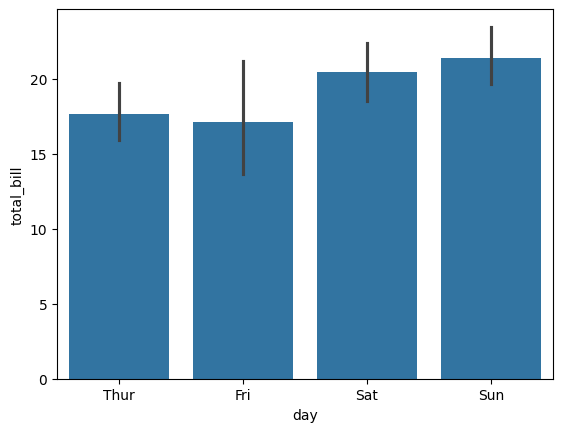

In [14]:
sns.barplot(x='day', y='total_bill', data=df)

<Axes: xlabel='total_bill', ylabel='Count'>

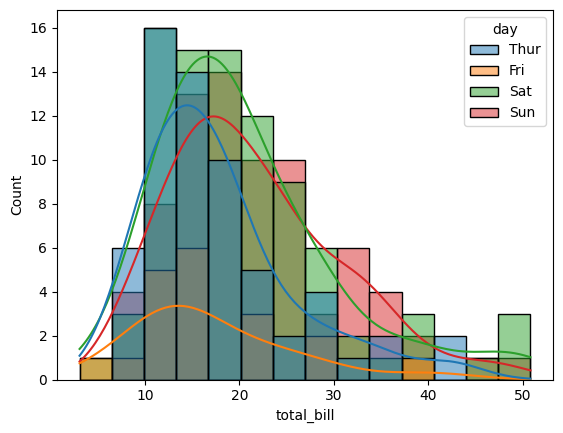

In [15]:
# hist plot with pclass grouping
sns.histplot(df, x='total_bill', hue='day', kde=True)

---
---

# Correlation

In [16]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: >

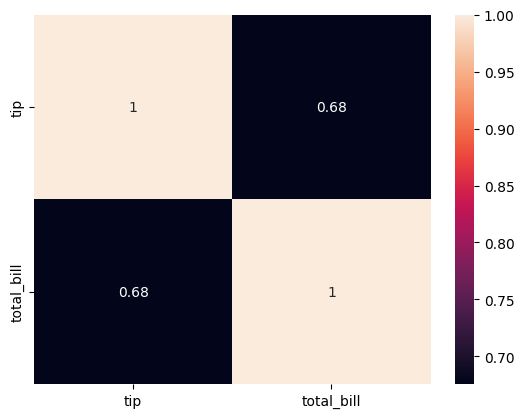

In [17]:
# create a heat map of correlation
sns.heatmap(df[['tip','total_bill']].corr(),annot=True)

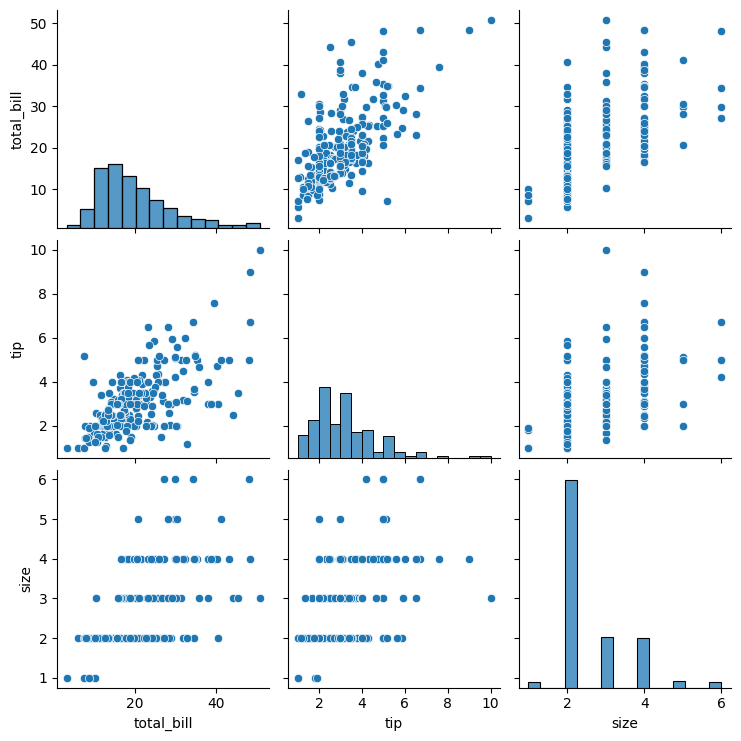

In [18]:
sns.pairplot(df)

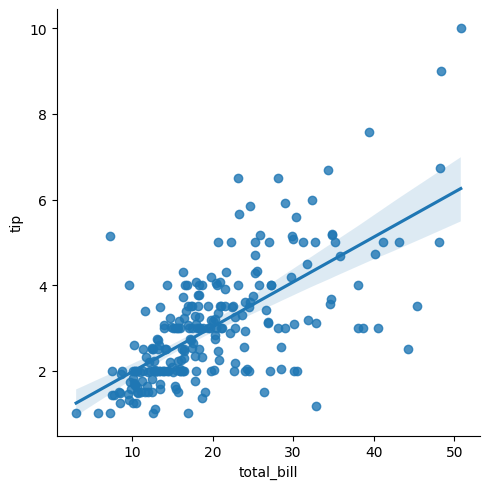

In [20]:
sns.lmplot(x='total_bill', y='tip', data=df)